Saving loan_approval_classification_dataset.csv to loan_approval_classification_dataset (3).csv
Dataset Loaded Successfully!

First 5 Records:
   Age  Income  CreditScore Employment Property LoanApproved
0   25   30000          580         No       No           No
1   35   60000          720        Yes      Yes          Yes
2   42   75000          760        Yes      Yes          Yes
3   28   40000          620        Yes       No           No
4   45   90000          800        Yes      Yes          Yes

Dataset Shape: (24, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           24 non-null     int64 
 1   Income        24 non-null     int64 
 2   CreditScore   24 non-null     int64 
 3   Employment    24 non-null     object
 4   Property      24 non-null     object
 5   LoanApproved  24 non-null     object
dtypes:

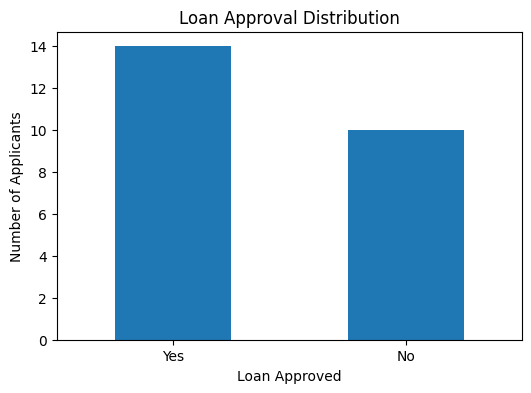

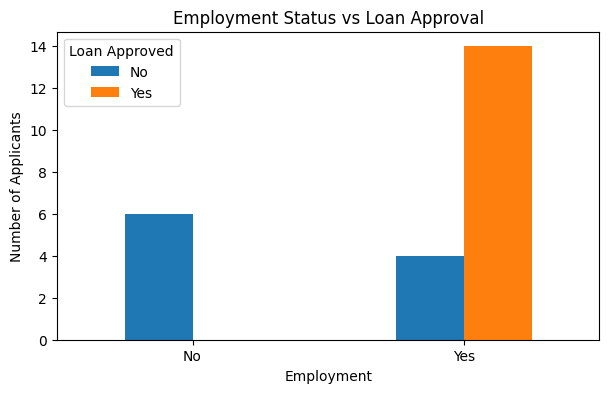

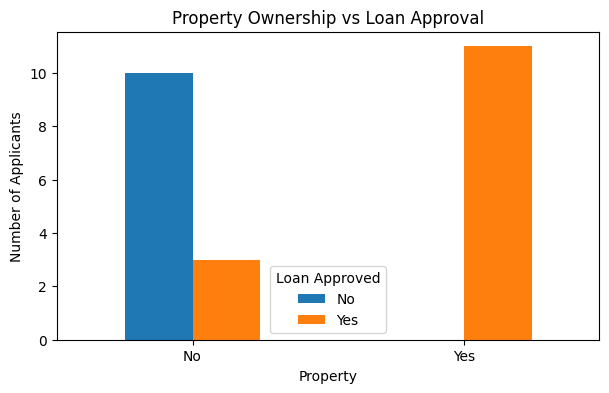

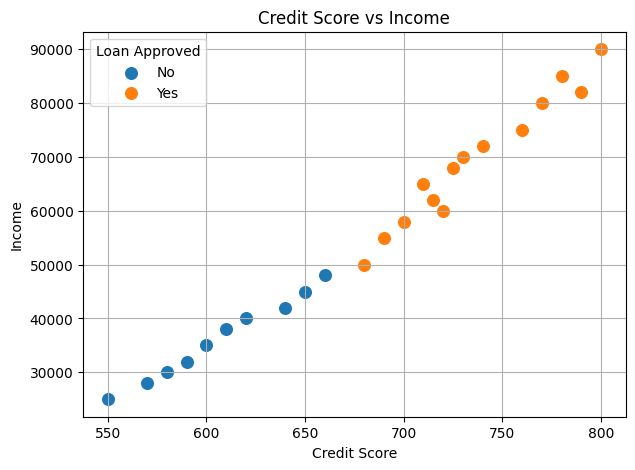


Encoded Dataset:
   Age  Income  CreditScore  Employment  Property  LoanApproved
0   25   30000          580           0         0             0
1   35   60000          720           1         1             1
2   42   75000          760           1         1             1
3   28   40000          620           1         0             0
4   45   90000          800           1         1             1

Features:
['Age', 'Income', 'CreditScore', 'Employment', 'Property']

Target: LoanApproved

RIPPER-STYLE CLASSIFICATION RULES
|--- Income <= 49000.00
|   |--- class: 0
|--- Income >  49000.00
|   |--- class: 1


RIPPER-Style Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



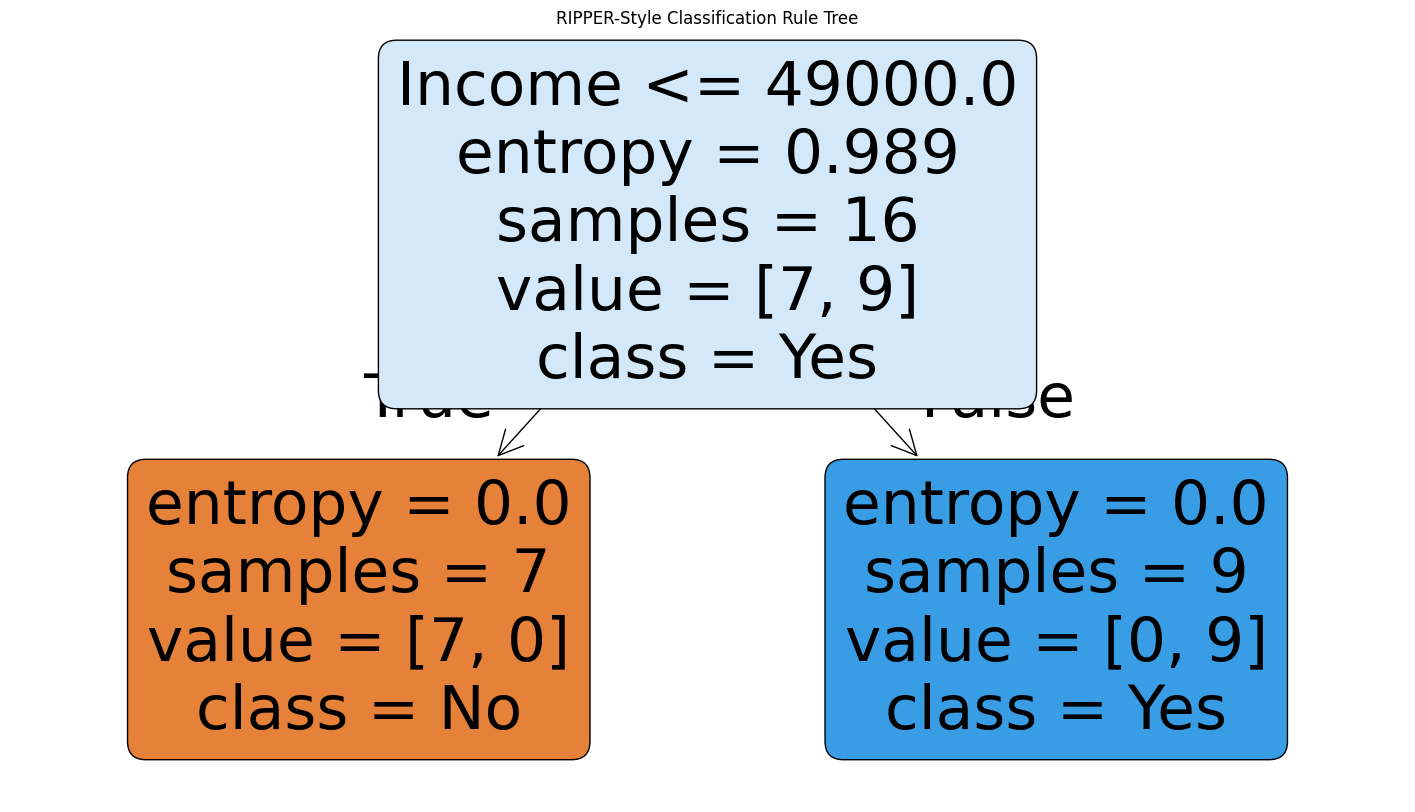


FOIL FIRST-ORDER CLASSIFICATION RULES
Rule 1: IF Property(X, Yes) THEN LoanApproved(X, Yes)
Rule 2: IF Employment(X, Yes) AND Age(X, 31) THEN LoanApproved(X, Yes)
Rule 3: IF Age(X, 36) THEN LoanApproved(X, Yes)
Rule 4: IF Age(X, 39) THEN LoanApproved(X, Yes)

FOIL RESULTS
FOIL Accuracy: 100.0 %

Actual vs FOIL Predicted:
   LoanApproved FOIL_Predicted
0            No             No
1           Yes            Yes
2           Yes            Yes
3            No             No
4           Yes            Yes
5           Yes            Yes
6            No             No
7           Yes            Yes
8            No             No
9           Yes            Yes
10           No             No
11          Yes            Yes
12           No             No
13          Yes            Yes
14          Yes            Yes
15          Yes            Yes
16           No             No
17          Yes            Yes
18           No             No
19          Yes            Yes
20           No          

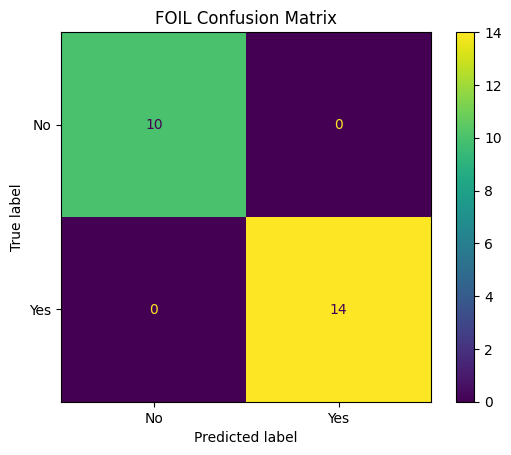

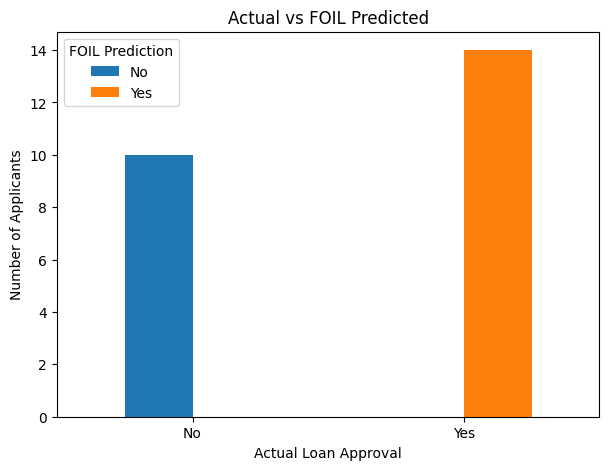

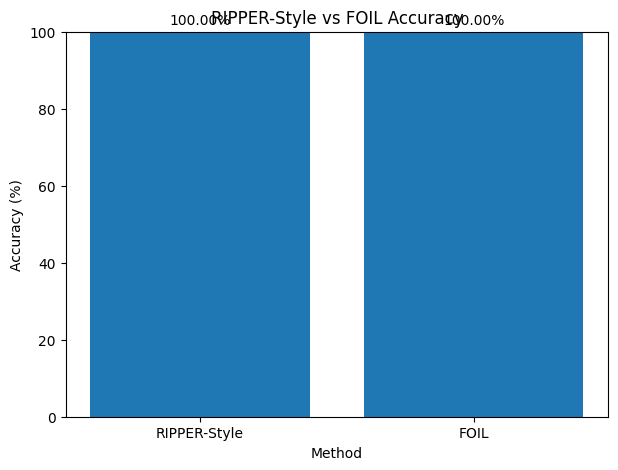


NEW APPLICANT PREDICTION

Applicant Details:
Age: 40
Income: 70000
CreditScore: 750
Employment: Yes
Property: Yes

FOIL Prediction: Yes

FINAL LEARNED FOIL RULES
Rule 1: IF Property(X, Yes) THEN LoanApproved(X, Yes)
Rule 2: IF Employment(X, Yes) AND Age(X, 31) THEN LoanApproved(X, Yes)
Rule 3: IF Age(X, 36) THEN LoanApproved(X, Yes)
Rule 4: IF Age(X, 39) THEN LoanApproved(X, Yes)

CONCLUSION
The Loan Approval dataset was classified using a RIPPER-style rule-based approach and the FOIL First-Order Inductive Learner. FOIL generated IF-THEN first-order classification rules and was used to predict loan approval for new applicants.


In [ ]:
# ============================================================
# PROBLEM STATEMENT:
# Read a dataset and use an example-based method (such as
# RIPPER or CN2) to generate a set of classification rules.
# Apply the FOIL algorithm (First-Order Inductive Learner)
# to learn first-order rules for predicting.
#
# Dataset: Loan Approval Classification Dataset
# ============================================================

# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. UPLOAD AND READ DATASET
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset Loaded Successfully!")
print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["LoanApproved"].value_counts())


# ============================================================
# 2. GRAPH - LOAN APPROVAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))
df["LoanApproved"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()


# ============================================================
# 3. GRAPH - EMPLOYMENT VS LOAN APPROVAL
# ============================================================

employment_table = pd.crosstab(
    df["Employment"],
    df["LoanApproved"]
)

employment_table.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Employment Status vs Loan Approval")
plt.xlabel("Employment")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Approved")
plt.show()


# ============================================================
# 4. GRAPH - PROPERTY VS LOAN APPROVAL
# ============================================================

property_table = pd.crosstab(
    df["Property"],
    df["LoanApproved"]
)

property_table.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Property Ownership vs Loan Approval")
plt.xlabel("Property")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Approved")
plt.show()


# ============================================================
# 5. GRAPH - CREDIT SCORE VS INCOME
# ============================================================

plt.figure(figsize=(7, 5))

for approval in df["LoanApproved"].unique():
    subset = df[df["LoanApproved"] == approval]

    plt.scatter(
        subset["CreditScore"],
        subset["Income"],
        label=approval,
        s=70
    )

plt.title("Credit Score vs Income")
plt.xlabel("Credit Score")
plt.ylabel("Income")
plt.legend(title="Loan Approved")
plt.grid(True)
plt.show()


# ============================================================
# 6. PREPROCESS DATA
# ============================================================

data = df.copy()

label_encoders = {}

for column in data.columns:
    if data[column].dtype == "object":
        encoder = LabelEncoder()
        data[column] = encoder.fit_transform(data[column])
        label_encoders[column] = encoder

print("\nEncoded Dataset:")
print(data.head())


# ============================================================
# 7. SEPARATE FEATURES AND TARGET
# ============================================================

X = data.drop("LoanApproved", axis=1)
y = data["LoanApproved"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget: LoanApproved")


# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ============================================================
# 9. RIPPER-STYLE RULE LEARNING
#
# Scikit-learn does not directly provide the original RIPPER
# algorithm, so a decision tree is used here to generate
# interpretable IF-THEN classification rules.
# ============================================================

ripper_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

ripper_model.fit(X_train, y_train)

print("\n================================================")
print("RIPPER-STYLE CLASSIFICATION RULES")
print("================================================")

rules = export_text(
    ripper_model,
    feature_names=list(X.columns)
)

print(rules)


# ============================================================
# 10. RIPPER-STYLE PREDICTION
# ============================================================

y_pred_ripper = ripper_model.predict(X_test)

ripper_accuracy = accuracy_score(
    y_test,
    y_pred_ripper
)

print("\nRIPPER-Style Accuracy:",
      round(ripper_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_ripper,
        target_names=label_encoders["LoanApproved"].classes_
    )
)


# ============================================================
# 11. DECISION TREE GRAPH
# ============================================================

plt.figure(figsize=(18, 10))

plot_tree(
    ripper_model,
    feature_names=X.columns,
    class_names=label_encoders["LoanApproved"].classes_,
    filled=True,
    rounded=True
)

plt.title("RIPPER-Style Classification Rule Tree")
plt.show()


# ============================================================
# 12. FOIL ALGORITHM
# ============================================================

# FOIL learns rules in the form:
#
# IF condition1 AND condition2 AND ...
# THEN LoanApproved = Yes
#
# Each rule is represented as:
# [
#   ("Attribute", "Value"),
#   ("Attribute", "Value")
# ]


def covers(example, rule):
    """
    Check whether an example satisfies all conditions
    in a rule.
    """
    for attribute, value in rule:
        if str(example[attribute]) != str(value):
            return False

    return True


def covered_examples(examples, rule):
    """
    Return examples covered by the rule.
    """
    return [
        example for example in examples
        if covers(example, rule)
    ]


def foil_gain(p0, n0, p1, n1):
    """
    Calculate FOIL information gain.
    """

    if p1 == 0:
        return -999

    if p0 + n0 == 0:
        return -999

    if p1 + n1 == 0:
        return -999

    old_probability = p0 / (p0 + n0)
    new_probability = p1 / (p1 + n1)

    if old_probability == 0 or new_probability == 0:
        return -999

    return p1 * (
        np.log2(new_probability) -
        np.log2(old_probability)
    )


# ============================================================
# 13. FOIL LEARNING FUNCTION
# ============================================================

def foil_learn(df):

    attributes = [
        column for column in df.columns
        if column != "LoanApproved"
    ]

    positive_examples = df[
        df["LoanApproved"] == "Yes"
    ].to_dict("records")

    negative_examples = df[
        df["LoanApproved"] == "No"
    ].to_dict("records")

    learned_rules = []

    while len(positive_examples) > 0:

        rule = []
        current_examples = positive_examples.copy()

        while True:

            current_negative = [
                example
                for example in negative_examples
                if covers(example, rule)
            ]

            if len(current_negative) == 0:
                break

            best_gain = -999
            best_condition = None

            for attribute in attributes:

                # Do not use the same attribute repeatedly
                used_attributes = [
                    condition[0]
                    for condition in rule
                ]

                if attribute in used_attributes:
                    continue

                values = df[attribute].unique()

                for value in values:

                    new_rule = rule + [
                        (attribute, value)
                    ]

                    positive_after = [
                        example
                        for example in positive_examples
                        if covers(example, new_rule)
                    ]

                    negative_after = [
                        example
                        for example in negative_examples
                        if covers(example, new_rule)
                    ]

                    p0 = len(current_examples)
                    n0 = len(current_negative)

                    p1 = len(positive_after)
                    n1 = len(negative_after)

                    gain = foil_gain(
                        p0,
                        n0,
                        p1,
                        n1
                    )

                    if gain > best_gain:
                        best_gain = gain
                        best_condition = (
                            attribute,
                            value
                        )

            if best_condition is None:
                break

            rule.append(best_condition)

            current_examples = [
                example
                for example in positive_examples
                if covers(example, rule)
            ]

            if len(current_examples) == 0:
                break

        if len(rule) == 0:
            break

        learned_rules.append(rule)

        # Remove positive examples covered by this rule
        positive_examples = [
            example
            for example in positive_examples
            if not covers(example, rule)
        ]

    return learned_rules


# ============================================================
# 14. TRAIN FOIL
# ============================================================

foil_rules = foil_learn(df)


# ============================================================
# 15. DISPLAY FOIL FIRST-ORDER RULES
# ============================================================

print("\n================================================")
print("FOIL FIRST-ORDER CLASSIFICATION RULES")
print("================================================")

if len(foil_rules) == 0:

    print("No rules were generated.")

else:

    for i, rule in enumerate(foil_rules, 1):

        conditions = []

        for attribute, value in rule:

            conditions.append(
                f"{attribute}(X, {value})"
            )

        rule_text = " AND ".join(conditions)

        print(
            f"Rule {i}: IF {rule_text} "
            f"THEN LoanApproved(X, Yes)"
        )


# ============================================================
# 16. FOIL PREDICTION FUNCTION
# ============================================================

def foil_predict(example, rules):

    for rule in rules:

        if covers(example, rule):
            return "Yes"

    return "No"


# ============================================================
# 17. APPLY FOIL TO DATASET
# ============================================================

foil_predictions = []

for _, row in df.iterrows():

    example = row.to_dict()

    prediction = foil_predict(
        example,
        foil_rules
    )

    foil_predictions.append(prediction)


df["FOIL_Predicted"] = foil_predictions


# ============================================================
# 18. FOIL ACCURACY
# ============================================================

foil_accuracy = accuracy_score(
    df["LoanApproved"],
    df["FOIL_Predicted"]
)

print("\n================================================")
print("FOIL RESULTS")
print("================================================")

print(
    "FOIL Accuracy:",
    round(foil_accuracy * 100, 2),
    "%"
)

print("\nActual vs FOIL Predicted:")
print(
    df[
        [
            "LoanApproved",
            "FOIL_Predicted"
        ]
    ]
)


# ============================================================
# 19. FOIL CONFUSION MATRIX
# ============================================================

foil_cm = confusion_matrix(
    df["LoanApproved"],
    df["FOIL_Predicted"],
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=foil_cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title("FOIL Confusion Matrix")
plt.show()


# ============================================================
# 20. ACTUAL VS FOIL PREDICTED GRAPH
# ============================================================

comparison = pd.crosstab(
    df["LoanApproved"],
    df["FOIL_Predicted"]
)

comparison.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Actual vs FOIL Predicted")
plt.xlabel("Actual Loan Approval")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="FOIL Prediction")
plt.show()


# ============================================================
# 21. COMPARE RIPPER-STYLE AND FOIL
# ============================================================

methods = [
    "RIPPER-Style",
    "FOIL"
]

accuracies = [
    ripper_accuracy * 100,
    foil_accuracy * 100
]

plt.figure(figsize=(7, 5))

plt.bar(
    methods,
    accuracies
)

plt.title("RIPPER-Style vs FOIL Accuracy")
plt.xlabel("Method")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()


# ============================================================
# 22. TEST A NEW APPLICANT
# ============================================================

new_applicant = {
    "Age": 40,
    "Income": 70000,
    "CreditScore": 750,
    "Employment": "Yes",
    "Property": "Yes"
}

foil_prediction = foil_predict(
    new_applicant,
    foil_rules
)

print("\n================================================")
print("NEW APPLICANT PREDICTION")
print("================================================")

print("\nApplicant Details:")

for key, value in new_applicant.items():
    print(f"{key}: {value}")

print(
    "\nFOIL Prediction:",
    foil_prediction
)


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print("\n================================================")
print("FINAL LEARNED FOIL RULES")
print("================================================")

for i, rule in enumerate(foil_rules, 1):

    conditions = []

    for attribute, value in rule:

        conditions.append(
            f"{attribute}(X, {value})"
        )

    print(
        f"Rule {i}: IF "
        + " AND ".join(conditions)
        + " THEN LoanApproved(X, Yes)"
    )

print("\n================================================")
print("CONCLUSION")
print("================================================")

print(
    "The Loan Approval dataset was classified using "
    "a RIPPER-style rule-based approach and the FOIL "
    "First-Order Inductive Learner. FOIL generated "
    "IF-THEN first-order classification rules and "
    "was used to predict loan approval for new applicants."
)